In [1]:
import os
os.chdir("/Users/yesicarb/Desktop/UIE/3º Curso/2 SEM/PROYECTO/emotion/multimodal_emotion")

import pandas as pd
import numpy as np
import json
import sys
sys.path.append("src")

from fusion.late_fusion import run_fusion
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data/processed/labels.csv")
print(f"Dataset: {df.shape}")

Dataset: (4869, 4)


In [2]:
# Reproducir el mismo split que usaron los módulos
le     = LabelEncoder()
labels = le.fit_transform(df['label'].tolist())
texts  = df['text'].tolist()

_, _, _, y_test = train_test_split(
    texts, labels,
    test_size=0.2, random_state=42, stratify=labels)

print(f"Test set: {len(y_test)} muestras")
print(f"Clases: {le.classes_}")

Test set: 974 muestras
Clases: ['negative' 'neutral' 'positive']


In [3]:
# Ejecutar fusión con Simulated Annealing
preds, fusion_probas, f1, history, best_weights = run_fusion(
    true_labels=y_test,
    class_names=le.classes_
)

Simulated Annealing iniciado
T0=1.0 · Tf=0.001 · alpha=0.95
F1 inicial (pesos iguales): 0.6881

SA completado en 135 iteraciones
Pesos óptimos encontrados:
  LR: 0.361
  BERT: 0.393
  SVM: 0.174
  ResNet: 0.072
Mejor F1: 0.7419

=== Late Fusion — Simulated Annealing ===
              precision    recall  f1-score   support

    negative       0.69      0.74      0.71       244
     neutral       0.74      0.73      0.74       384
    positive       0.79      0.77      0.78       346

    accuracy                           0.74       974
   macro avg       0.74      0.74      0.74       974
weighted avg       0.75      0.74      0.74       974

F1 macro final: 0.7419


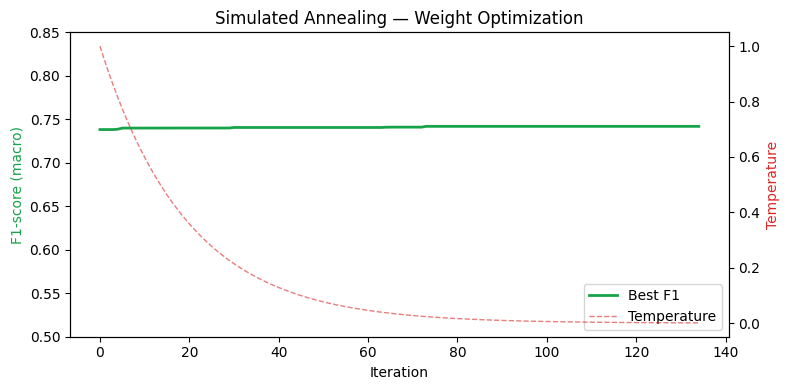

Gráfica guardada en results/figures/sa_convergence.png


In [4]:
# Gráfica de convergencia del SA
import matplotlib.pyplot as plt

temps   = [h['T'] for h in history]
f1_hist = [h['best_f1'] for h in history]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(f1_hist, color='#16a34a', linewidth=2, label='Best F1')
ax2.plot(temps,   color='#dc2626', linewidth=1,
         linestyle='--', alpha=0.6, label='Temperature')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('F1-score (macro)', color='#16a34a')
ax2.set_ylabel('Temperature', color='#dc2626')
ax1.set_title('Simulated Annealing — Weight Optimization')
ax1.set_ylim(0.5, 0.85)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.savefig('results/figures/sa_convergence.png', dpi=150)
plt.show()
print("Gráfica guardada en results/figures/sa_convergence.png")

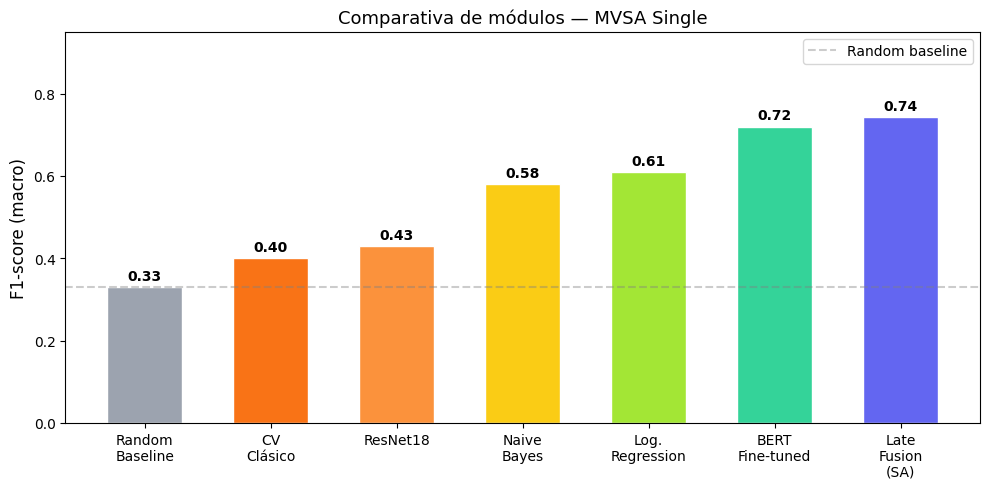

In [5]:
# Gráfica comparativa final con resultados del SA
modulos   = ['Random\nBaseline', 'CV\nClásico', 'ResNet18',
             'Naive\nBayes', 'Log.\nRegression',
             'BERT\nFine-tuned', 'Late\nFusion\n(SA)']
f1_scores = [0.33, 0.40, 0.43, 0.58, 0.61, 0.72, f1]
colors    = ['#9ca3af', '#f97316', '#fb923c',
             '#facc15', '#a3e635', '#34d399', '#6366f1']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(modulos, f1_scores, color=colors,
              width=0.6, edgecolor='white')

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylim(0, 0.95)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title('Comparativa de módulos — MVSA Single', fontsize=13)
ax.axhline(y=0.33, color='gray', linestyle='--',
           alpha=0.4, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/fusion_comparison.png', dpi=150)
plt.show()

In [6]:
# Guardar resultados finales
import json
import numpy as np

results_final = {
    'f1_macro':     f1,
    'best_weights': {
        'LR':     float(best_weights[0]),
        'BERT':   float(best_weights[1]),
        'SVM':    float(best_weights[2]),
        'ResNet': float(best_weights[3])
    },
    'method': 'Simulated Annealing',
    'sa_params': {
        'T0':    1.0,
        'Tf':    0.001,
        'alpha': 0.95,
        'max_iter': 500
    }
}

with open('results/metrics_fusion_sa.json', 'w') as f:
    json.dump(results_final, f, indent=2)

print("Resultados guardados en results/metrics_fusion_sa.json")
print(f"\nResumen final:")
print(f"  Método: Simulated Annealing")
print(f"  F1 macro: {f1:.4f}")
print(f"  Pesos: LR={best_weights[0]:.3f} · "
      f"BERT={best_weights[1]:.3f} · "
      f"SVM={best_weights[2]:.3f} · "
      f"ResNet={best_weights[3]:.3f}")

Resultados guardados en results/metrics_fusion_sa.json

Resumen final:
  Método: Simulated Annealing
  F1 macro: 0.7419
  Pesos: LR=0.361 · BERT=0.393 · SVM=0.174 · ResNet=0.072
